<a href="https://colab.research.google.com/github/afunny101/Taiwan_ALDH2_Alcohol_Kinetics_Education_Project/blob/main/ALDH2_Alcohol_Kinetics_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 100

age = np.random.randint(20, 65, n)
genotype = np.random.choice(["normal", "mutant"], n, p=[0.6, 0.4])
initial_conc = np.random.uniform(10, 80, n)

# 代謝速率差異
rate = []

for g, c in zip(genotype, initial_conc):
    if g == "normal":
        if c < 40:
            r = 0.05 * c  # 一級
        else:
            r = 2.0       # 零級
    else:
        if c < 40:
            r = 0.03 * c
        else:
            r = 1.0
    rate.append(r)

df = pd.DataFrame({
    "age": age,
    "genotype": genotype,
    "initial_concentration": initial_conc,
    "metabolism_rate": rate
})

df.head()

,age,genotype,initial_concentration,metabolism_rate
0,58,mutant,16.732359,0.501971
1,48,mutant,75.836629,1.000000
2,34,mutant,37.830041,1.134901
3,62,mutant,46.242595,1.000000
4,27,mutant,68.639707,1.000000


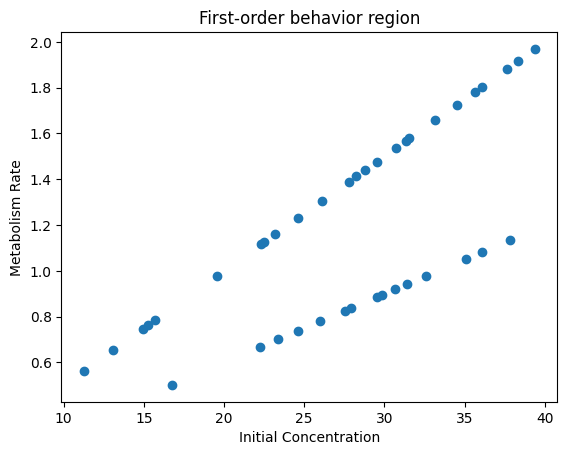

In [2]:
subset = df[df["initial_concentration"] < 40]

plt.scatter(subset["initial_concentration"], subset["metabolism_rate"])
plt.xlabel("Initial Concentration")
plt.ylabel("Metabolism Rate")
plt.title("First-order behavior region")
plt.show()

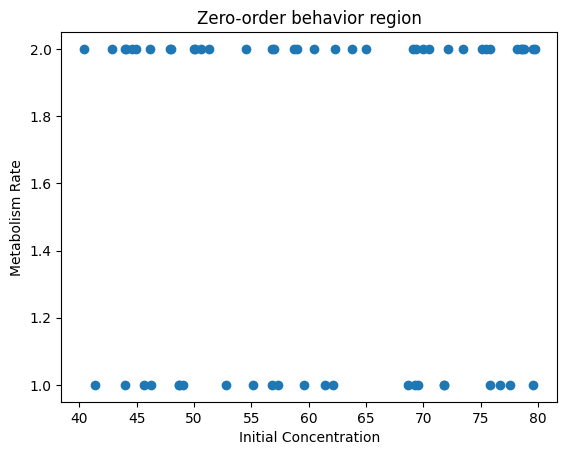

In [3]:
subset2 = df[df["initial_concentration"] >= 40]

plt.scatter(subset2["initial_concentration"], subset2["metabolism_rate"])
plt.xlabel("Initial Concentration")
plt.ylabel("Metabolism Rate")
plt.title("Zero-order behavior region")
plt.show()

In [4]:
students = pd.DataFrame({
    "group": range(1, 11),
    "correct_identification": np.random.choice([0,1], 10, p=[0.3,0.7])
})

students

,group,correct_identification
0,1,0
1,2,1
2,3,0
3,4,0
4,5,1
5,6,0
6,7,1
7,8,0
8,9,1
9,10,1


In [6]:
df.to_csv("aldh2_data.csv", index=False)
students.to_csv("education_data.csv", index=False)

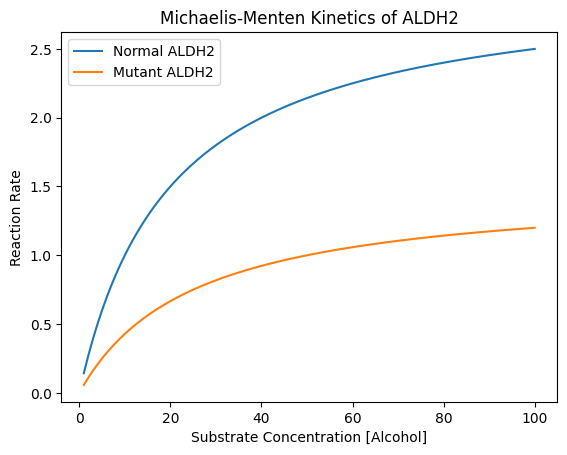

In [11]:
import numpy as np
import matplotlib.pyplot as plt
def michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)
def michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)
Vmax_normal = 3.0
Km_normal = 20

Vmax_mutant = 1.5
Km_mutant = 25

S = np.linspace(1, 100, 200)

v_normal = michaelis_menten(S, Vmax_normal, Km_normal)
v_mutant = michaelis_menten(S, Vmax_mutant, Km_mutant)

plt.plot(S, v_normal)
plt.plot(S, v_mutant)

plt.xlabel("Substrate Concentration [Alcohol]")
plt.ylabel("Reaction Rate")
plt.title("Michaelis-Menten Kinetics of ALDH2")

plt.legend(["Normal ALDH2", "Mutant ALDH2"])
plt.show()

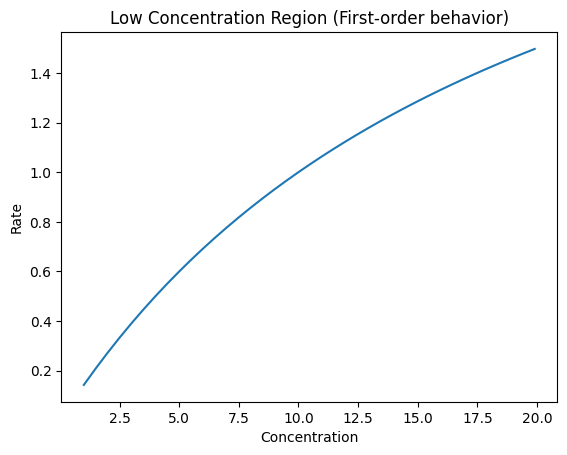

In [12]:
low_region = S[S < 20]
v_low = michaelis_menten(low_region, Vmax_normal, Km_normal)

plt.plot(low_region, v_low)
plt.title("Low Concentration Region (First-order behavior)")
plt.xlabel("Concentration")
plt.ylabel("Rate")
plt.show()

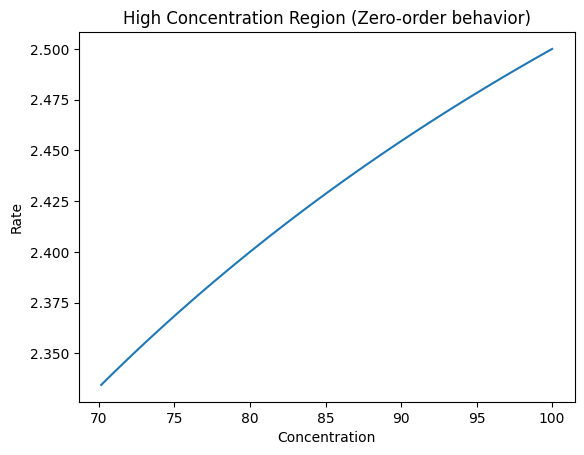

In [13]:
high_region = S[S > 70]
v_high = michaelis_menten(high_region, Vmax_normal, Km_normal)

plt.plot(high_region, v_high)
plt.title("High Concentration Region (Zero-order behavior)")
plt.xlabel("Concentration")
plt.ylabel("Rate")
plt.show()

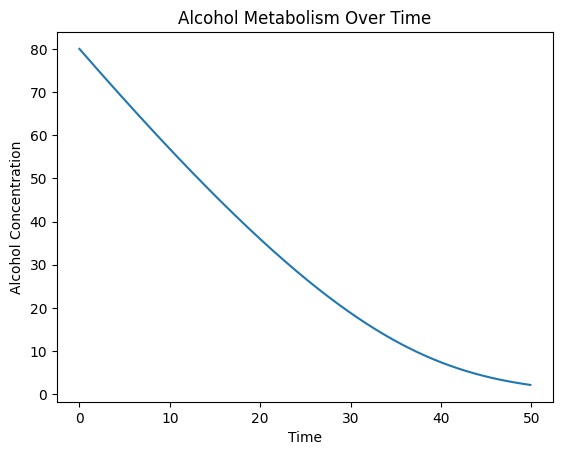

In [14]:
dt = 0.1
time = np.arange(0, 50, dt)

S_time = np.zeros(len(time))
S_time[0] = 80

for i in range(1, len(time)):
    dS = -michaelis_menten(S_time[i-1], Vmax_normal, Km_normal)
    S_time[i] = S_time[i-1] + dS * dt

plt.plot(time, S_time)
plt.xlabel("Time")
plt.ylabel("Alcohol Concentration")
plt.title("Alcohol Metabolism Over Time")
plt.show()